









# NUTDTS 816 Time Series Analysis
## L01 Introduction to time series data

Lab notebook for Chapter 1 of the lecture notes. Run the setup cell first. Every code cell reproduces an example from the notes; the exercises at the end are from the chapter's self-check list.

**Instructor:** Dr Tolulope Adesina · NUTM MSc Data Science · 2026

In [4]:
# ---- Setup: run once per Colab session ----
# 1. Install the course libraries (about two minutes the first time)
!pip install -q statsmodels pmdarima statsforecast neuralforecast lightgbm arch plotly

# 2. Fetch the course data module and data snapshots from the course repository.
#    Replace REPO with your fork if you do not want to work from the official course repository URL.
REPO = "https://raw.githubusercontent.com/toadesina/NUTDTS816_Course_Repository/main"
import urllib.request, os
os.makedirs("data", exist_ok=True)
urllib.request.urlretrieve(f"{REPO}/src/tsdata.py", "tsdata.py")
DATA_FILES = ["nigeria_cpi", "nigeria_fx", "nigeria_grid", "nigeria_malaria", "nigeria_rainfall", "bonny_light", "daily_demand",
              "airpassengers", "a10", "h02", "ausbeer", "elecequip", "usmelec", "goog", "nile", "austourists", "oil", "dax", "uschange", "elecdemand"]
for f in DATA_FILES:
    urllib.request.urlretrieve(f"{REPO}/data/{f}.csv", f"data/{f}.csv")

import warnings; warnings.filterwarnings("ignore")
import pandas as pd, numpy as np, matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9, 3.6), "axes.grid": True, "grid.alpha": 0.3, "axes.spines.top": False, "axes.spines.right": False})
import tsdata
print("Setup complete.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 501.8/501.8 kB 29.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 308.0/308.0 kB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 982.9/982.9 kB 46.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.7/348.7 kB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.0/281.0 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 831.6/831.6 kB 40.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.3/78.3 MB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.4/267.4 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

### 1.6 Working with time series in pandas

In [5]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
import tsdata   # course data module (real fpp2/R datasets; simulated Nigerian-shaped series)

ap = tsdata.airpassengers()      # monthly international airline passengers, 1949-1960 (thousands)
print(type(ap), ap.index.freq)
print(ap.head(6))
print(ap.index[:3])

<class 'pandas.core.series.Series'> <MonthBegin>
date
1949-01-01    112
1949-02-01    118
1949-03-01    132
1949-04-01    129
1949-05-01    121
1949-06-01    135
Freq: MS, Name: passengers, dtype: int64
DatetimeIndex(['1949-01-01', '1949-02-01', '1949-03-01'], dtype='datetime64[ns]', name='date', freq='MS')


In [6]:
# A messy extract, as you might receive it from a portal
raw = pd.DataFrame({
    'period': ['2024-01', '2024-02', '2024-03', '2024-05', '2024-05', '2024-06', '2024-08'],
    'cpi':    [  743.1,    752.6,    766.0,     787.9,     787.9,    803.4,     828.7]})
raw['date'] = pd.to_datetime(raw['period'], format='%Y-%m')
s = raw.drop_duplicates('date').set_index('date')['cpi']
s = s.asfreq('MS')                       # impose a regular monthly grid; gaps become NaN
print(s)
print('missing:', s.isna().sum())

date
2024-01-01    743.1
2024-02-01    752.6
2024-03-01    766.0
2024-04-01      NaN
2024-05-01    787.9
2024-06-01    803.4
2024-07-01      NaN
2024-08-01    828.7
Freq: MS, Name: cpi, dtype: float64
missing: 2


In [7]:
s_filled = s.interpolate(method='linear')   # simple, defensible for a smooth monthly index
print(s_filled.round(1))

date
2024-01-01    743.1
2024-02-01    752.6
2024-03-01    766.0
2024-04-01    777.0
2024-05-01    787.9
2024-06-01    803.4
2024-07-01    816.0
2024-08-01    828.7
Freq: MS, Name: cpi, dtype: float64


In [8]:
dem = tsdata.elecdemand()    # half-hourly electricity demand, Victoria (Australia), 2014
print(dem.head(3))
daily = dem['Demand'].resample('D').sum()          # daily total demand (GW-halfhours)
monthly_mean = dem['Demand'].resample('MS').mean() # monthly mean half-hourly demand
print(daily.head(3).round(1)); print(monthly_mean.round(2).head(3))

                       Demand  WorkDay  Temperature
date                                               
2014-01-01 00:00:00  3.914647        0         18.2
2014-01-01 00:30:00  3.672550        0         17.9
2014-01-01 01:00:00  3.497539        0         17.6
date
2014-01-01    174.9
2014-01-02    188.6
2014-01-03    188.9
Freq: D, Name: Demand, dtype: float64
date
2014-01-01    4.83
2014-02-01    4.82
2014-03-01    4.40
Freq: MS, Name: Demand, dtype: float64


In [9]:
cpi  = tsdata.nigeria_cpi()     # monthly CPI, Jan 2015 - Jun 2026 (simulated)
fx   = tsdata.nigeria_fx()      # monthly NGN/USD, Jan 2015 - Jun 2026 (simulated)
grid = tsdata.nigeria_grid()    # monthly average grid generation, MW (simulated)
print(pd.concat([cpi, fx, grid], axis=1).tail(4))

            cpi    ngn_usd  generation_mw
date                                     
2026-04-01  NaN  1360.7185         3500.0
2026-05-01  NaN  1369.4947            NaN
2026-06-01  NaN  1366.4902            NaN
2026-07-01  NaN  1372.7523            NaN


## Exercises

1. For each of the following, state the natural frequency, the seasonal period(s) $m$, and whether you expect the series to be additive or multiplicative: hourly grid frequency; monthly rice prices in Lagos; quarterly Nigerian GDP; daily visits to a hospital emergency department; weekly cholera cases.
2. The `a10` series in the course data module is monthly antidiabetic drug sales in Australia. Produce the time plot, the log time plot, a seasonal plot and the ACF of the first difference of the log. Describe the trend, the seasonality and its type. What happens every January, and why might that be?
3. Simulate a random walk $x_t = x_{t-1} + \varepsilon_t$ with $\varepsilon_t \sim N(0,1)$ for $T = 200$ and plot its ACF. Explain why the ACF looks like that of a trending series even though the process has no deterministic trend.

## ANSWERS TO EXERCISE #1

##A) Hourly grid frequency

*   Natural frequency: Hourly
*   Seasonal period m: m = 24 daily; m = 168 weekly
*   Expected seasonality: Multiplicative

##B) Monthly rice prices in Lagos

*   Natural frequency: Monthly
*   Seasonal period m: m = 12 yearly
*   Expected seasonality: Multiplicative

##C) Quarterly Nigerian GDP

*   Natural frequency: Quarterly
*   Seasonal period m: m = 4 yearly
*   Expected seasonality: Additive

##D) Daily visits to hospital emergency department

*   Natural frequency: Daily
*   Seasonal period m: m = 7 weekly; m ≈ 365 yearly (possibly)
*   Expected seasonality: Additive

##E) Weekly cholera cases

*   Natural frequency: Weekly
*   Seasonal period m: m= 7 weekly; m ≈ 52 yearly
*   Expected seasonality: Multiplicative



## ANSWERS TO EXERCISE #2

In [10]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
import tsdata

a10 = tsdata.a10()
print(type(a10), a10.index.freq)
print(a10.head(6))
print(a10.index[:3])

<class 'pandas.core.series.Series'> <MonthBegin>
date
1991-07-01    3.526591
1991-08-01    3.180891
1991-09-01    3.252221
1991-10-01    3.611003
1991-11-01    3.565869
1991-12-01    4.306371
Freq: MS, Name: a10, dtype: float64
DatetimeIndex(['1991-07-01', '1991-08-01', '1991-09-01'], dtype='datetime64[ns]', name='date', freq='MS')


##A) Time plot

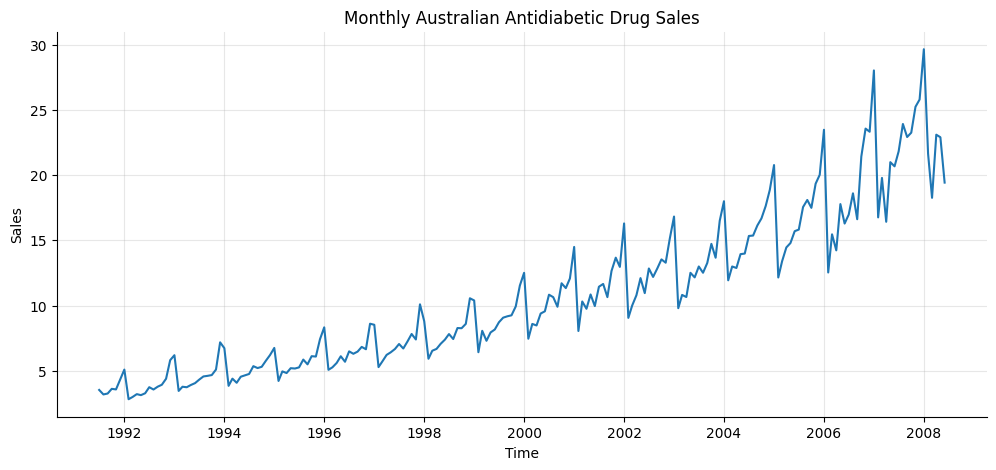

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(a10)
plt.title("Monthly Australian Antidiabetic Drug Sales")
plt.xlabel("Time")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

##B) Log time plot

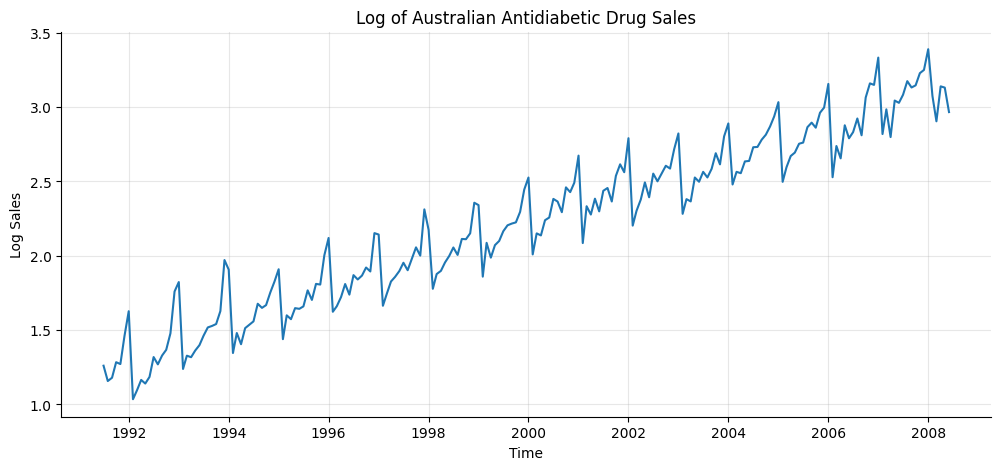

In [23]:
import numpy as np

log_a10 = np.log(a10)

plt.figure(figsize=(12, 5))
plt.plot(log_a10)
plt.title("Log of Australian Antidiabetic Drug Sales")
plt.xlabel("Time")
plt.ylabel("Log Sales")
plt.grid(True)
plt.show()

##C) Seasonal plot

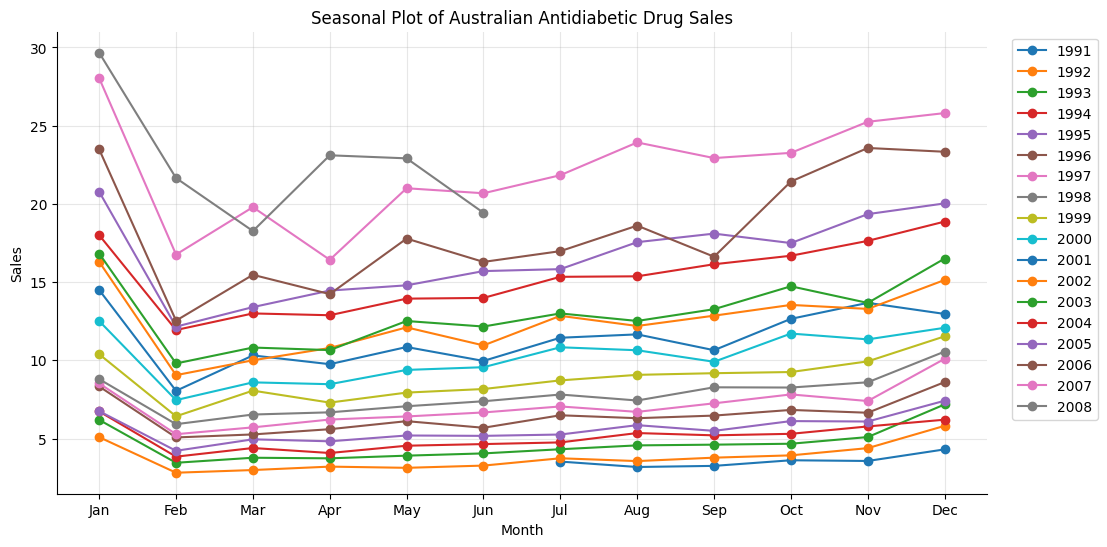

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame({"sales": a10})

df["year"] = df.index.year
df["month"] = df.index.month

plt.figure(figsize=(12, 6))

for year, group in df.groupby("year"):
    plt.plot(group["month"], group["sales"], marker="o", label=str(year))

plt.xticks(
    range(1, 13),
    ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
     "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
)

plt.xlabel("Month")
plt.ylabel("Sales")
plt.title("Seasonal Plot of Australian Antidiabetic Drug Sales")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(True)
plt.show()

##D) ACF plot

<Figure size 1200x500 with 0 Axes>

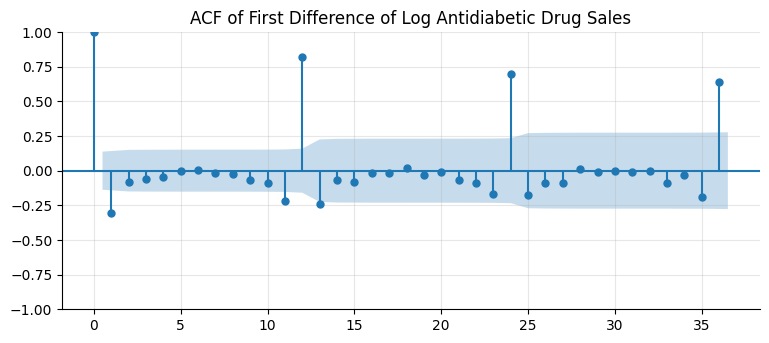

In [27]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(12, 5))
plot_acf(log_diff, lags=36)
plt.title("ACF of First Difference of Log Antidiabetic Drug Sales")
plt.show()

##E) Description of the trend, seasonality, and its type


*   **Trend**: There is a strong upward trend over time. Antidiabetic drug sales generally increrase as the years progress, although there are short-term fluctuations around the overall trend.
*   **Seasonality**: There is a clear annual seasonality. The sales pattern repeats approximately every 12 months, meaning the same months tend to show similar patterns from year tot year.
*   **Typer of seasonality**: The seasonality is multiplicative. This is because the size of the seasonal fluctuations increases as the overall level of sales increases. In other words, the seasonal variation becomes larger when the sales level is higher.
*   **What happens every January**: January tends to behave differently from the other months because antidiabetic drug sales have a recurring annual seasonal pattern.
*   **Why it has to be**: This has to be because January itself, rather than causing the disease, it could be as a result of calender and/or holiday-related changes in inventoty, purchasing, precriptions, and healthcare activity.







## ANSWERS TO EXERCISE #3

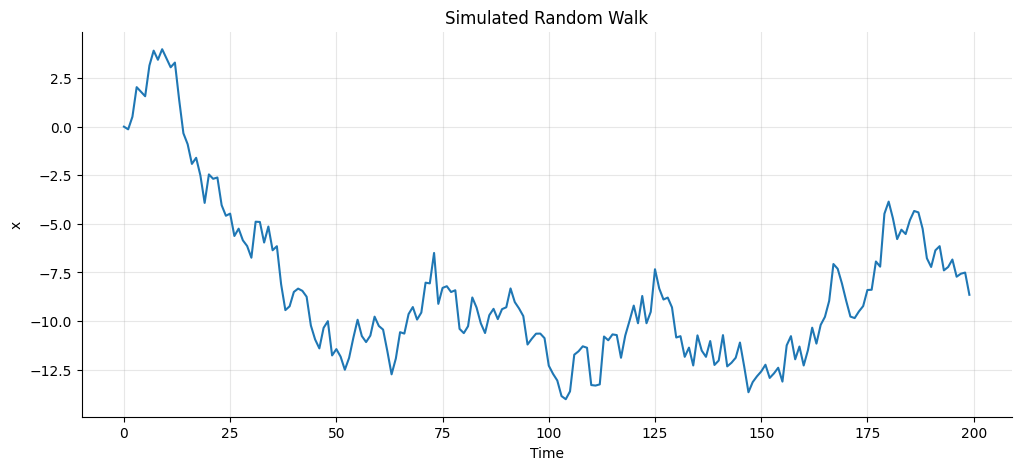

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

# Set seed so the result is reproducible
np.random.seed(42)

T = 200

# Generate random errors
epsilon = np.random.normal(0, 1, T)

# Create random walk
x = np.zeros(T)

for t in range(1, T):
    x[t] = x[t-1] + epsilon[t]

# Plot the random walk
plt.figure(figsize=(12, 5))
plt.plot(x)
plt.title("Simulated Random Walk")
plt.xlabel("Time")
plt.ylabel("x")
plt.grid(True)
plt.show()


<Figure size 1200x500 with 0 Axes>

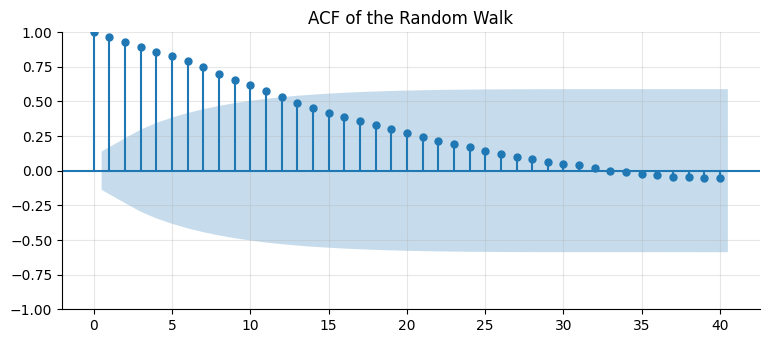

In [31]:
plt.figure(figsize=(12, 5))
plot_acf(x, lags=40)
plt.title("ACF of the Random Walk")
plt.show()

##Explanation to why the ACF looks like that of a trending series even though the process has no deterministic trend.

*   The ACF looks like that of a trending series because a random walk is non-stationary and each observation contains the accumulated effect of all previous shokcs. This creates strong positvie autocorrelation that decays slowly with increasing lag. Although the simulated series may appaer to trend, there is no deterministic trend; the apparent trend is generated by accumulated random shocks.